# Add-ons para Regressão Logística em datasets desequilibrados

A experiência avalia uma implementação de Regressão Logística em datasets binários com **class imbalance**. A versão base é comparada com variantes que alteram o treino, o gradiente ou a regra de decisão final, com o objetivo de melhorar a deteção da classe minoritária sem degradar demasiado o desempenho na classe maioritária.

## Estrutura do repositório e instruções de execução

```text
assignment/
|-- PracticalAssignment_ML1.pdf
|-- pyproject.toml
|-- uv.lock
|-- class_imbalance/
|   |-- dataset_*.csv
|-- outputs/
|   |-- addon_performance/
|   |   |-- config.json
|   |   |-- raw_results.csv
|   |   |-- model_summary.csv
|   |   |-- dataset_summary.csv
|-- src/
|   |-- analyze_addon_performance_results.ipynb
|   |-- analyze_addon_performance.py
|   |-- datasets.py
|   |-- logistic_regression.py
|   |-- metrics.py
```

Para preparar o ambiente a partir da raiz do repositório:

```bash
uv sync
uv run python -m ipykernel install --user --name assignment --display-name "assignment"
```

Para reproduzir as tabelas e gráficos a partir dos resultados guardados, abrir `src/analyze_addon_performance_results.ipynb`, escolher o kernel `assignment`, manter `RUN_FULL_EXPERIMENT = False` e executar todas as células.

Para recalcular a experiência do zero, mudar `RUN_FULL_EXPERIMENT = True` na próxima célula e executar todas as células. A mesma experiência também pode ser lançada pela linha de comandos:

```bash
uv run python src/analyze_addon_performance.py
```

A execução completa treina 16 modelos em 19 datasets e 20 seeds, ou seja, 6080 treinos. Os ficheiros em `outputs/addon_performance` correspondem à execução analisada nas secções seguintes.

## 1. Reproducibilidade

Os resultados analisados abaixo podem ser regenerados a partir de `src/analyze_addon_performance.py`. Esse script usa a Regressão Logística implementada em `src/logistic_regression.py` e os datasets preparados em `class_imbalance`.

Por defeito, a experiência completa não é recalculada nesta execução. A razão é prática: `19 datasets x 20 seeds x 16 modelos = 6080` execuções. Quando `RUN_FULL_EXPERIMENT = False`, a análise lê os ficheiros já produzidos em `outputs/addon_performance`.

Se a flag `RUN_FULL_EXPERIMENT` for colocada a `True`, todos os modelos são treinados novamente e os CSVs usados nas tabelas e figuras são recriados.

Os 16 modelos vêm das combinações dos 4 add-ons implementados. O subconjunto vazio corresponde ao `default`; os outros 15 modelos combinam um ou mais add-ons.

In [41]:
RUN_FULL_EXPERIMENT = False

if RUN_FULL_EXPERIMENT:
    import sys
    from pathlib import Path

    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
    SRC_DIR = PROJECT_ROOT / "src"
    OUTPUT_DIR = PROJECT_ROOT / "outputs" / "addon_performance"

    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    from analyze_addon_performance import (
        DATASET_LOADERS,
        build_models,
        default_config,
        run_experiment,
    )

    experiment_config = default_config()
    run_experiment(
        output_dir=OUTPUT_DIR,
        config=experiment_config,
        datasets=list(DATASET_LOADERS),
        models=list(build_models(experiment_config)),
        seeds=list(range(20)),
        timeout_seconds=1800,
        resume=False,
    )
else:
    print("Experiência completa não executada. A usar os resultados já guardados em outputs/addon_performance.")


Experiência completa não executada. A usar os resultados já guardados em outputs/addon_performance.


## 2. Carregar os resultados

Os ficheiros lidos nesta secção são:

- `raw_results.csv`: uma linha por dataset, seed e modelo treinado com sucesso;
- `model_summary.csv`: médias, medianas e desvios-padrão por modelo;
- `dataset_summary.csv`: melhor modelo por dataset e por métrica;
- `errors.csv`: execuções que falharam, quando existirem;
- `config.json`: hiperparâmetros usados na experiência.

In [42]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "addon_performance"

raw_results = pd.read_csv(OUTPUT_DIR / "raw_results.csv")
model_summary = pd.read_csv(OUTPUT_DIR / "model_summary.csv")
dataset_summary = pd.read_csv(OUTPUT_DIR / "dataset_summary.csv")
errors = pd.read_csv(OUTPUT_DIR / "errors.csv") if (OUTPUT_DIR / "errors.csv").exists() else pd.DataFrame()

with (OUTPUT_DIR / "config.json").open(encoding="utf-8") as file:
    config = json.load(file)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)


In [43]:
dataset_count = raw_results["dataset"].nunique()
seed_count = raw_results["seed"].nunique()
model_count = raw_results["model"].nunique()
expected_runs = dataset_count * seed_count * model_count

summary = pd.DataFrame(
    [
        {"item": "datasets", "value": dataset_count},
        {"item": "seeds", "value": seed_count},
        {"item": "modelos", "value": model_count},
        {"item": "execuções esperadas", "value": expected_runs},
        {"item": "execuções com sucesso", "value": len(raw_results)},
        {"item": "execuções com erro", "value": len(errors)},
        {"item": "pares dataset/seed com resultados", "value": raw_results[["dataset", "seed"]].drop_duplicates().shape[0]},
    ]
)

print(f"Conta da experiência: {dataset_count} datasets × {seed_count} seeds × {model_count} modelos = {expected_runs} execuções")
display(summary)
display(pd.DataFrame(config.get("analysis_config", config), index=["valor"]).T)


Conta da experiência: 19 datasets × 20 seeds × 16 modelos = 6080 execuções


,item,value
0,datasets,19
1,seeds,20
2,modelos,16
3,execuções esperadas,6080
4,execuções com sucesso,6080
5,execuções com erro,0
6,pares dataset/seed com resultados,380


,valor
cagd_alpha,5.0
cagd_approximation,diagonal
cagd_epsilon,0.01
focal_alpha,0.5
focal_gamma,2.0
gaar_c_minority,25.0
gaar_lambda,0.01
iterations,1000
learning_rate,0.01


## 3. Desequilíbrio de classes

O grupo de datasets escolhido foi o de **class imbalance em classificação binária**. Em `datasets.py`, cada dataset é normalizado para a mesma convenção:

- `target = 0`: classe maioritária;
- `target = 1`: classe minoritária.

Esta convenção é importante porque uma accuracy alta pode ser enganadora. Se um dataset tiver 1000 exemplos e só 20 forem positivos, um modelo que prevê sempre `0` acerta 980 vezes. A accuracy seria 98%, mas o modelo não encontrou nenhum exemplo da classe que mais nos interessa.

Por isso, a avaliação dá mais peso a métricas que mostram o comportamento nas duas classes:

- **majority recall**: percentagem dos exemplos da classe 0 reconhecidos como 0;
- **minority recall**: percentagem dos exemplos da classe 1 reconhecidos como 1;
- **balanced accuracy**: média dos dois recalls;
- **minority precision**: entre as previsões positivas, quantas estavam certas;
- **minority F1**: compromisso entre precision e recall da classe minoritária.

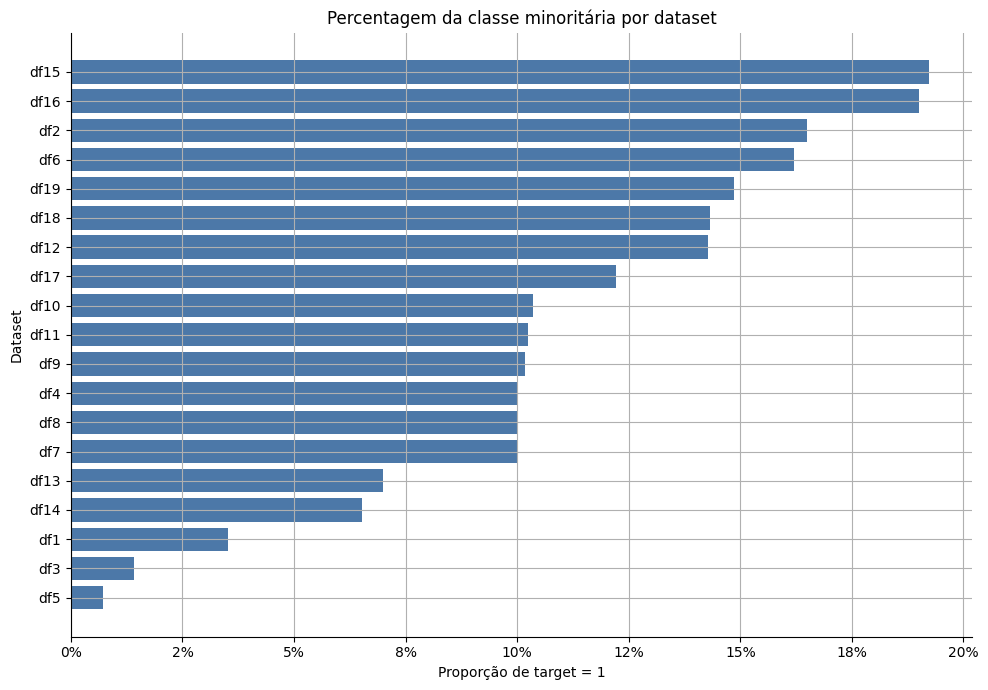

,dataset,target_0_count,target_1_count,rows,minority_ratio
1280,df5,9398,68,9466,0.0072
640,df3,2383,34,2417,0.0141
0,df1,4080,149,4229,0.0352
4160,df14,129,9,138,0.0652
3840,df13,93,7,100,0.0700
1920,df7,1800,200,2000,0.1000
2240,df8,1800,200,2000,0.1000
960,df4,1800,200,2000,0.1000
2560,df9,5048,572,5620,0.1018
3200,df11,4913,560,5473,0.1023


In [44]:
dataset_counts = (
    raw_results.drop_duplicates("dataset")
    [["dataset", "target_0_count", "target_1_count", "rows"]]
    .copy()
)
dataset_counts["minority_ratio"] = dataset_counts["target_1_count"] / dataset_counts["rows"]
dataset_counts = dataset_counts.sort_values("minority_ratio")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(dataset_counts["dataset"], dataset_counts["minority_ratio"], color="#4C78A8")
ax.set_title("Percentagem da classe minoritária por dataset")
ax.set_xlabel("Proporção de target = 1")
ax.set_ylabel("Dataset")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

display(dataset_counts.round(4))


## 4. Implementação da Regressão Logística

A Regressão Logística foi implementada em `src/logistic_regression.py`. A versão base aprende os pesos por gradient descent e usa threshold 0.5 para transformar probabilidades em classes.

Uso básico:

```python
from logistic_regression import LogisticRegression

model = LogisticRegression(learning_rate=0.01, iterations=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

A hipótese de partida foi esta: em datasets muito desequilibrados, a LR default tende a proteger a classe maioritária, porque a loss agregada é dominada pelos muitos exemplos negativos. Os add-ons foram desenhados para mexer nesse comportamento por caminhos diferentes.

Exemplos de configuração:

```python
model = LogisticRegression(addons=[Gaar(lambda_=0.01)])
model = LogisticRegression(addons=[CAGD(alpha=5.0, epsilon=1e-3)])
model = LogisticRegression(addons=[WeightedErrors(gamma=2.0), Gaar(lambda_=0.01)])
model = LogisticRegression(addons=["f1_threshold"])  # requer conjunto de validação
```

Além do modelo base, foram implementados 4 add-ons:

- **default**: Regressão Logística normal, com threshold 0.5, usada como referência.
- **WeightedErrors / focal loss**: reduz o peso de exemplos já fáceis e aumenta o impacto relativo dos exemplos difíceis.
- **GAAR**: adiciona ao gradiente um termo assimétrico. No código, os exemplos da classe minoritária recebem um peso maior (`c_minority = 25`).
- **CAGD**: reescala o gradiente usando uma aproximação da curvatura dos dados, com maior peso para a classe minoritária.
- **F1Threshold**: depois do treino, escolhe no conjunto de validação o threshold que maximiza o F1 da classe positiva.

Em termos práticos:

- GAAR e WeightedErrors mexem no **erro durante o treino**;
- CAGD mexe na **escala do passo do gradiente**;
- F1Threshold mexe na **regra de decisão final**.

### 4.1. Weighted Errors (Focal Loss)

Na Regressão Logística normal, o erro usado no gradiente é `p - y`. Assim, todos os exemplos entram com a mesma regra:

| y | p | erro (p-y) |
| --- | --- | --- |
| 1 | 0,9 | 0,1 |
| 1 | 0,2 | 0,8 |

Neste exemplo, o caso difícil já pesa cerca de 8 vezes mais do que o caso fácil. A focal loss torna essa diferença ainda mais forte, multiplicando o erro por:

$Peso = \alpha_t(1 - p_t)^\gamma$

No artigo de Lin et al. (2017), *Focal Loss for Dense Object Detection*, valores comuns são:

$\alpha_t = 0.5$

$\gamma = 2$

Aplicando esses valores ao mesmo exemplo:

| y | p | erro (p-y) | 0,5*(1-p_t)**2 | novo erro |
| --- | --- | --- | --- | --- |
| 1 | 0,9 | 0,1 | 0,005 | 0,0005 |
| 1 | 0,2 | 0,8 | 0,320 | 0,2560 |

A diferença relativa passa de 8x para 512x. Na prática, o gradiente deixa de ser gasto sobretudo em exemplos que o modelo já classifica bem.

### 4.2. Gradient Asymmetric Additive Regularization (GAAR)

Na implementação, o gradiente base é calculado primeiro e depois cada add-on pode ajustar `dw`:

```python
dw = np.dot(X.T, error) / len(y)
db = np.mean(error)

for addon in self.addons:
    dw += addon.gradient_adjustment(X, y, probabilities, error)
```

O GAAR adiciona uma penalização baseada na norma ao quadrado do gradiente da loss de cada exemplo:

$\Omega = \frac{\lambda}{n} \sum_{i=1}^{n} c_i ||\nabla_w l_i(w)||^2$

Para Regressão Logística, $\nabla_w l_i(w) = (p_i - y_i)x_i$. Logo:

$\nabla_w \Omega = \frac{\lambda}{n} \sum_{i=1}^{n} 2c_i(p_i - y_i)p_i(1-p_i)||x_i||^2x_i$

No código, a parte escalar de cada exemplo é calculada em `scale` e depois multiplicada por `X.T`:

```python
scale = 2 * c * error * sigmoid_deriv * x_norms_sq
return self.lambda_ * np.dot(X.T, scale) / n
```

Este termo altera apenas `dw`; o bias `db` fica igual ao da LR default.

Exemplo com $\lambda=0.1$ e $c_{min}=10$. Aqui a classe positiva (`y = 1`) é a minoritária, como no código. Numa versão mais afinada, `c_min` poderia depender da proporção de classes de cada dataset; neste trabalho mantive esse valor fixo para reduzir o número de graus de liberdade.

| X | y | erro | pesos iniciais (w) |
| --- | --- | --- | --- |
| 2 | 1 | -0,5 | 0 |
| 1 | 0 | 0,5 | 0 |

Com pesos iniciais a zero, o sigmoide é 0.5 para as duas amostras, logo $P = [0.50, 0.50]$.

Gradiente da LR default:

$d_w = np.dot(X.T, error) / len(y)$

$d_w = ([2, 1]^T . [-0.5, 0.5]) / 2$

$d_w = (-1 + 0.5) / 2 = -0.25$

Com GAAR:

1. Peso por classe:

   $c = np.where(y == 1, self.c_{minority}, 1.0) = [10.0, 1.0]$

2. Derivada do sigmoide:

   $sigmoid\_deriv = probabilities * (1 - probabilities) = [0.25, 0.25]$

3. Vetor `scale`:

   $x\_norms\_sq = np.sum(X**2, axis=1) = [4.0, 1.0]$

   $scale = 2*c*error*sigmoid\_deriv*x\_norms\_sq = [-10, 0.25]$

4. Ajuste do gradiente:

   $d_{w-gaar} = 0.1/2 * X^T * scale = 0.05*(2*(-10) + 1*0.25) = -0.9875$

5. Gradiente final:

   $dw = dw_{default} + d_{w-gaar} = -1.2375$

Neste exemplo, o termo extra empurra o treino com muito mais força na direção que reduz o erro da classe minoritária.

### 4.3. Class Asymmetric Gradient Descent (CAGD)

Na LR default, o gradiente por amostra é:

$\nabla_w l_i(w) = (p_i - y_i)x_i$

O CAGD reescala o gradiente usando uma aproximação da curvatura da loss. Para Regressão Logística, essa curvatura por amostra é:

$v_i = p_i(1-p_i)$

A Hessiana empírica pode ser escrita como:

$H = \frac{1}{N}\sum_{i=1}^{N}v_ix_ix_i^T$

O CAGD separa esta curvatura por classe:

$H_0 = \frac{1}{N}\sum_{i \in \{j|y_j=0\}}v_ix_ix_i^T$

$H_1 = \frac{1}{N}\sum_{i \in \{j|y_j=1\}}v_ix_ix_i^T$

Depois constrói o precondicionador:

$P = H_0 + \alpha H_1 + \epsilon I$

E aplica esse precondicionador ao gradiente batch `dw`:

$dw_{CAGD} = P^{-1}dw$

Na experiência foi usada a versão diagonal (`approximation="diagonal"`). Assim, em vez de inverter uma matriz completa, o código usa apenas a diagonal de $P$ e faz uma divisão elemento a elemento:

```python
preconditioner_diagonal = hessian_0_diagonal + self.alpha * hessian_1_diagonal + self.epsilon
return gradient / preconditioner_diagonal
```

Usando o mesmo exemplo da secção anterior, com $\alpha = 5.0$ e ignorando $\epsilon$ só para simplificar a conta:

| X | y | erro | pesos iniciais (w) |
| --- | --- | --- | --- |
| 2 | 1 | -0,5 | 0 |
| 1 | 0 | 0,5 | 0 |

Temos:

$H_0 = \frac{1}{2}(0.5(1-0.5))1^2 = 0.125$

$H_1 = \frac{1}{2}(0.5(1-0.5))2^2 = 0.5$

$P = 0.125 + 5*0.5 = 2.625$

Então:

$dw_{CAGD} = P^{-1}dw = \frac{-0.25}{2.625} = -0.0952$

Com o valor usado no script ($\epsilon = 0.01$), o denominador passa a 2.635 e o gradiente fica aproximadamente -0.0949. Tal como no GAAR, o bias `db` não é alterado pelo CAGD.

### 4.4. F1 Threshold

Os três add-ons anteriores alteram o treino. O `F1Threshold` é diferente: ele mantém os pesos e o bias aprendidos, mas troca a regra que transforma probabilidades em classes.

No fim do `fit`, o modelo escolhe um threshold usando o conjunto de validação:

```python
self._select_threshold(X_val, y_val)
```

Dentro do add-on, o código calcula probabilidades no conjunto de validação e testa thresholds entre 0.01 e 0.99:

```python
probabilities = model.predict_proba(X_val)
self.threshold, self.score = self.find_best_f1_threshold(probabilities, y_val, self.thresholds)
```

Para cada threshold, a decisão é:

$\hat{y}_i = 1 \text{ se } p_i \geq t, \text{ senão } 0$

Depois é calculado o F1 da classe positiva:

$F1 = \frac{2TP}{2TP + FP + FN}$

O threshold escolhido é o que dá o maior F1 no conjunto de validação. Em datasets desequilibrados, o threshold 0.5 costuma ser conservador: evita falsos positivos, mas também deixa escapar muitos positivos reais.

Exemplo simples:

| amostra | y | probabilidade |
| --- | --- | --- |
| 1 | 1 | 0.90 |
| 2 | 1 | 0.40 |
| 3 | 0 | 0.35 |
| 4 | 0 | 0.20 |

Com threshold default $t = 0.5$:

$\hat{y} = [1, 0, 0, 0]$

$TP = 1, FP = 0, FN = 1$

$F1 = \frac{2*1}{2*1 + 0 + 1} = 0.667$

Com threshold $t = 0.3$:

$\hat{y} = [1, 1, 1, 0]$

$TP = 2, FP = 1, FN = 0$

$F1 = \frac{2*2}{2*2 + 1 + 0} = 0.800$

Neste exemplo, baixar o threshold recupera um positivo que antes era falso negativo. O preço é criar um falso positivo. Esse é exatamente o trade-off que o add-on tenta controlar.

## 5. O que o script `analyze_addon_performance.py` faz

O script faz uma comparação controlada. Em vez de treinar um modelo uma única vez e tratar esse valor como definitivo, a experiência é repetida em vários datasets e várias seeds.

Para cada par dataset/seed, o processo é:

1. dividir os dados em treino, validação e teste;
2. treinar o modelo `default` e todas as variantes com add-ons;
3. avaliar todos os modelos no mesmo conjunto de teste;
4. guardar métricas como balanced accuracy, minority recall, minority F1, ROC AUC e average precision;
5. comparar cada variante com o `default` no mesmo par dataset/seed.

O último ponto é a parte que torna a comparação justa. A comparação é **emparelhada**: se uma divisão dos dados é mais fácil ou mais difícil, isso afeta o `default` e a variante da mesma forma. Assim, a diferença observada fica menos dependente do acaso de uma split específica.

In [45]:
model_order = model_summary.sort_values("balanced_accuracy_mean", ascending=False)["model"].tolist()

run_counts = (
    raw_results.groupby("model", as_index=False)
    .size()
    .rename(columns={"size": "execuções com sucesso"})
    .sort_values("execuções com sucesso")
)

display(run_counts)


,model,execuções com sucesso
0,cagd,380
1,cagd_f1_threshold,380
2,default,380
3,f1_threshold,380
4,focal_loss,380
5,focal_loss_cagd,380
6,focal_loss_cagd_f1_threshold,380
7,focal_loss_f1_threshold,380
8,gaar,380
9,gaar_cagd,380


## 6. Resultado médio por modelo

A primeira leitura é o resumo por modelo, ordenado por balanced accuracy média.

Como interpretar a tabela:

- balanced accuracy alta indica que o modelo não está a sacrificar completamente uma das classes;
- minority recall alto significa que o modelo encontrou mais exemplos positivos;
- minority F1 alto mostra que esse aumento de positivos encontrados não veio apenas de prever `1` em todo o lado;
- accuracy gain over majority compara o modelo com a baseline trivial que prevê sempre a classe maioritária.

In [46]:
summary_columns = [
    "model",
    "balanced_accuracy_mean",
    "minority_recall_mean",
    "minority_f1_mean",
    "average_precision_mean",
    "roc_auc_mean",
    "accuracy_gain_over_majority_mean",
    "mean_training_time_seconds",
    "runs",
]

display(
    model_summary.sort_values("balanced_accuracy_mean", ascending=False)[summary_columns]
    .round(4)
)


,model,balanced_accuracy_mean,minority_recall_mean,minority_f1_mean,average_precision_mean,roc_auc_mean,accuracy_gain_over_majority_mean,mean_training_time_seconds,runs
0,cagd_f1_threshold,0.7907,0.7056,0.6048,0.6793,0.8933,-0.0231,2.9631,380
1,gaar_cagd_f1_threshold,0.7881,0.7115,0.6069,0.6824,0.8860,-0.0322,3.9835,380
2,gaar_cagd,0.7869,0.6106,0.5614,0.6824,0.8860,0.0430,3.9771,380
3,gaar_focal_loss_cagd_f1_threshold,0.7780,0.7016,0.5962,0.6679,0.8784,-0.0426,4.0330,380
4,focal_loss_cagd_f1_threshold,0.7773,0.6959,0.5852,0.6558,0.8815,-0.0395,2.9877,380
5,gaar_f1_threshold,0.7721,0.6811,0.5820,0.6569,0.8727,-0.0413,1.4197,380
6,f1_threshold,0.7645,0.6676,0.5622,0.6325,0.8649,-0.0438,0.4037,380
7,gaar_focal_loss_f1_threshold,0.7640,0.6773,0.5614,0.6353,0.8648,-0.0524,1.4565,380
8,gaar_focal_loss_cagd,0.7560,0.5744,0.4639,0.6679,0.8784,0.0123,4.0196,380
9,cagd,0.7538,0.5304,0.5406,0.6793,0.8933,0.0480,2.9716,380


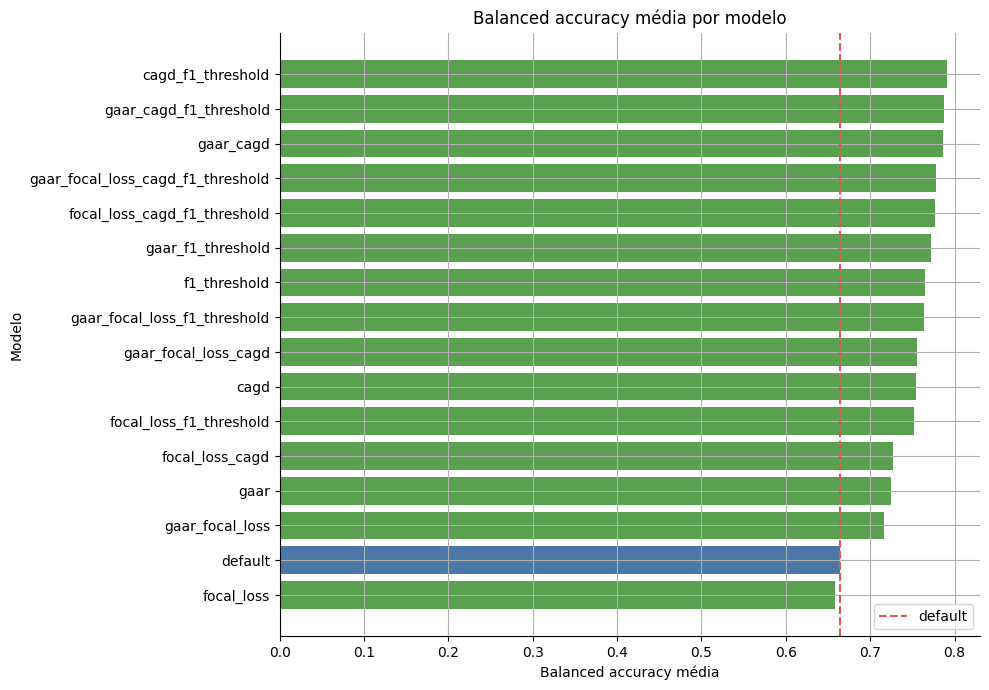

In [47]:
plot_df = model_summary.sort_values("balanced_accuracy_mean", ascending=True)
colors = ["#59A14F" if name != "default" else "#4C78A8" for name in plot_df["model"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["model"], plot_df["balanced_accuracy_mean"], color=colors)
ax.set_title("Balanced accuracy média por modelo")
ax.set_xlabel("Balanced accuracy média")
ax.set_ylabel("Modelo")
ax.axvline(
    model_summary.loc[model_summary["model"] == "default", "balanced_accuracy_mean"].iloc[0],
    color="#E15759",
    linestyle="--",
    label="default",
)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Comparar várias métricas ao mesmo tempo

Nenhuma métrica conta a história inteira. Um modelo pode aumentar muito o recall da classe minoritária e, ao mesmo tempo, piorar a accuracy global por gerar demasiados falsos positivos.

A figura seguinte junta as principais métricas numa só vista. Cores mais claras representam valores maiores.

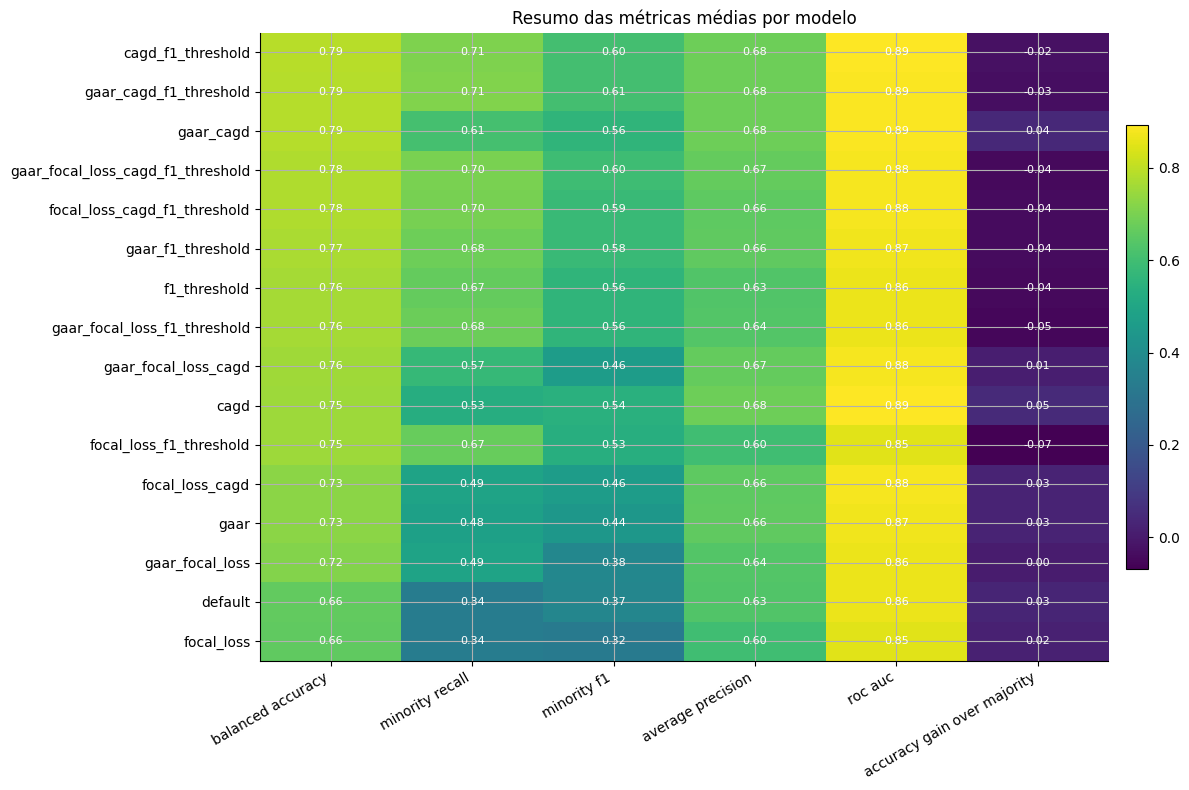

In [48]:
heatmap_metrics = [
    "balanced_accuracy_mean",
    "minority_recall_mean",
    "minority_f1_mean",
    "average_precision_mean",
    "roc_auc_mean",
    "accuracy_gain_over_majority_mean",
]

heatmap_df = (
    model_summary.set_index("model")
    .loc[model_order, heatmap_metrics]
)

fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")
ax.set_title("Resumo das métricas médias por modelo")
ax.set_xticks(np.arange(len(heatmap_metrics)))
ax.set_xticklabels([col.replace("_mean", "").replace("_", " ") for col in heatmap_metrics], rotation=30, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for row in range(heatmap_df.shape[0]):
    for col in range(heatmap_df.shape[1]):
        ax.text(col, row, f"{heatmap_df.iloc[row, col]:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()


## 8. O compromisso entre encontrar positivos e manter qualidade geral

O objetivo não é simplesmente prever positivo em todo o lado. O gráfico seguinte mostra o compromisso central deste trabalho:

- eixo X: recall médio da classe maioritária;
- eixo Y: recall médio da classe minoritária;
- tamanho do ponto: F1 médio da classe minoritária.

O canto ideal seria perto do topo direito: recuperar muitos positivos sem destruir o desempenho na classe maioritária.

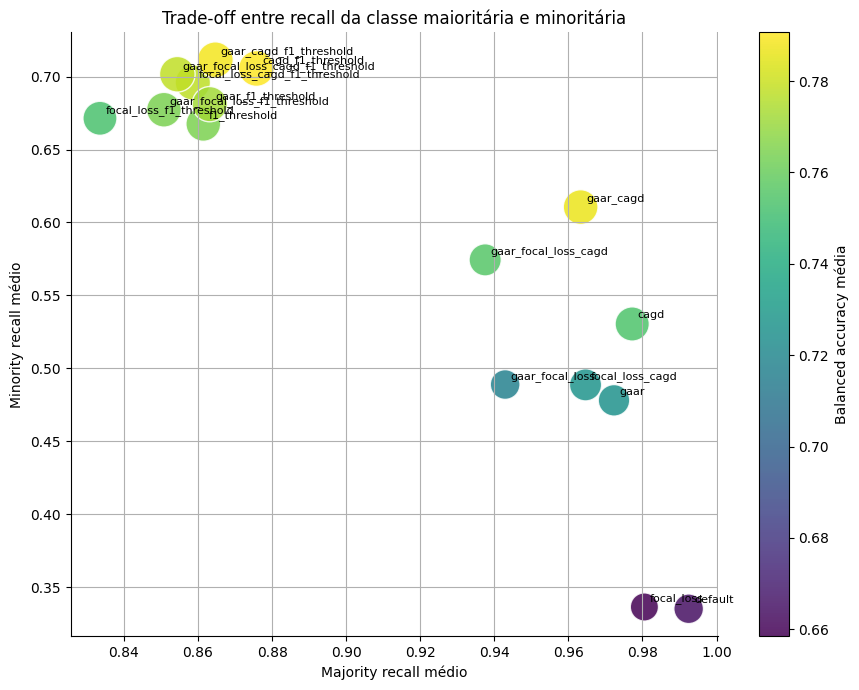

In [49]:
tradeoff = (
    raw_results.groupby("model", as_index=False)
    .agg(
        majority_recall_mean=("majority_recall", "mean"),
        minority_recall_mean=("minority_recall", "mean"),
        minority_f1_mean=("minority_f1", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(9, 7))
sizes = 120 + 900 * tradeoff["minority_f1_mean"]
scatter = ax.scatter(
    tradeoff["majority_recall_mean"],
    tradeoff["minority_recall_mean"],
    s=sizes,
    c=tradeoff["balanced_accuracy_mean"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="white",
)

for _, row in tradeoff.iterrows():
    ax.annotate(row["model"], (row["majority_recall_mean"], row["minority_recall_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("Trade-off entre recall da classe maioritária e minoritária")
ax.set_xlabel("Majority recall médio")
ax.set_ylabel("Minority recall médio")
fig.colorbar(scatter, ax=ax, label="Balanced accuracy média")
plt.tight_layout()
plt.show()


## 9. CD diagram: comparar modelos por rank médio

As médias globais são úteis, mas podem esconder diferenças importantes. Um modelo pode ser excelente em poucos datasets e mediano nos restantes. Por isso também comparei os modelos por rank médio em cada dataset.

O procedimento foi:

1. calcular a média da métrica escolhida para cada par dataset/modelo, agregando as seeds;
2. dentro de cada dataset, ordenar os modelos por desempenho;
3. transformar essa ordenação em ranks, onde rank 1 é o melhor;
4. calcular o rank médio de cada modelo;
5. usar o teste pós-hoc de Nemenyi para obter a matriz de p-values;
6. passar os ranks médios e a matriz de p-values para `scikit_posthocs.critical_difference_diagram`.

No gráfico, quanto mais à esquerda estiver o modelo, melhor é o seu desempenho relativo médio. As barras horizontais ligam modelos que o teste de Nemenyi não separa estatisticamente ao nível `alpha = 0.05`.

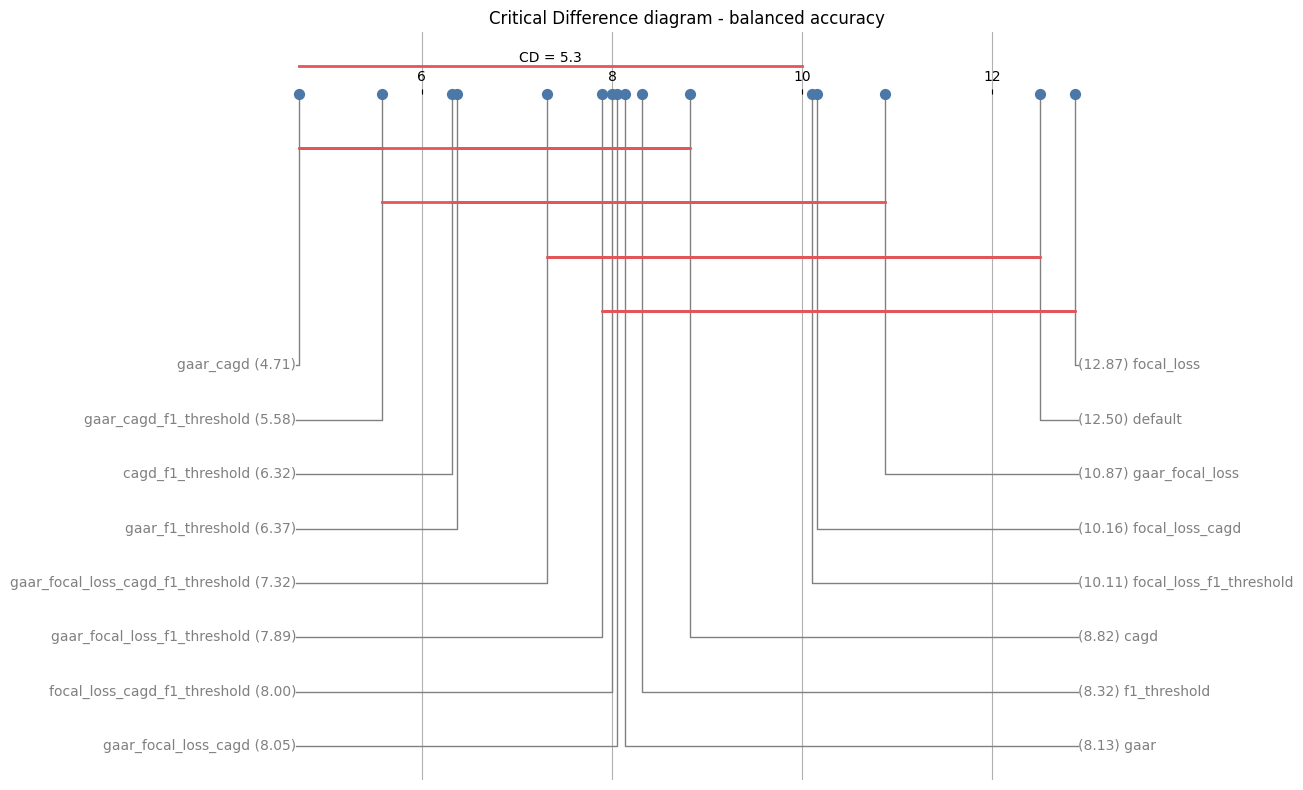

,model,average_rank
0,gaar_cagd,4.7105
1,gaar_cagd_f1_threshold,5.5789
2,cagd_f1_threshold,6.3158
3,gaar_f1_threshold,6.3684
4,gaar_focal_loss_cagd_f1_threshold,7.3158
5,gaar_focal_loss_f1_threshold,7.8947
6,focal_loss_cagd_f1_threshold,8.0000
7,gaar_focal_loss_cagd,8.0526
8,gaar,8.1316
9,f1_threshold,8.3158


In [50]:
import scikit_posthocs as sp
from scipy.stats import studentized_range

CD_METRIC = "balanced_accuracy"
ALPHA = 0.05


def metric_matrix(results, metric):
    return (
        results.groupby(["dataset", "model"], as_index=False)[metric]
        .mean()
        .pivot(index="dataset", columns="model", values=metric)
    )


def nemenyi_critical_difference(number_of_models, number_of_datasets, alpha=0.05):
    q_alpha = studentized_range.ppf(
        1 - alpha,
        number_of_models,
        np.inf,
    ) / np.sqrt(2)
    return q_alpha * np.sqrt(
        number_of_models * (number_of_models + 1) / (6 * number_of_datasets)
    )


score_matrix = metric_matrix(raw_results, CD_METRIC)
rank_matrix = score_matrix.rank(axis=1, ascending=False, method="average")
average_rank = rank_matrix.mean(axis=0).sort_values()

# posthoc_nemenyi_friedman ranks lower values as better. Because our metric is
# better when higher, we pass the negative score matrix.
nemenyi_p_values = sp.posthoc_nemenyi_friedman(-score_matrix)
nemenyi_p_values = nemenyi_p_values.loc[average_rank.index, average_rank.index]

cd = nemenyi_critical_difference(
    number_of_models=rank_matrix.shape[1],
    number_of_datasets=rank_matrix.shape[0],
    alpha=ALPHA,
)

fig, ax = plt.subplots(figsize=(13, 8))
sp.critical_difference_diagram(
    average_rank,
    nemenyi_p_values,
    cd=cd,
    alpha=ALPHA,
    ax=ax,
    label_fmt_left="{label} ({rank:.2f})",
    label_fmt_right="({rank:.2f}) {label}",
    marker_props={"s": 50, "color": "#4C78A8"},
    elbow_props={"color": "#808080", "linewidth": 1.0},
    crossbar_props={"color": "#E15759", "linewidth": 2.0},
    text_h_margin=0.03,
)
ax.set_title(f"Critical Difference diagram - {CD_METRIC.replace('_', ' ')}")
plt.tight_layout()
plt.show()

display(
    average_rank.rename("average_rank")
    .reset_index()
    .rename(columns={"model": "model"})
    .round(4)
)


## 10. Erros durante a experiência

O script mantém as execuções falhadas separadas dos resultados válidos. Quando um modelo produz probabilidades não finitas ou falha noutra etapa, o erro fica em `errors.csv` e essa linha não entra em `raw_results.csv`.

Isto evita contaminar as médias com execuções incompletas. Ao mesmo tempo, a tabela de erros ajuda a perceber se algum dataset ou alguma combinação de add-ons é instável.

In [52]:
if errors.empty:
    print("Não houve erros registados.")
else:
    error_summary = (
        errors.groupby(["dataset", "model", "error_type"], as_index=False)
        .size()
        .rename(columns={"size": "erros"})
        .sort_values(["erros", "dataset", "model"], ascending=[False, True, True])
    )
    display(error_summary.head(30))

    fig, ax = plt.subplots(figsize=(10, 5))
    by_dataset = errors.groupby("dataset").size().sort_values()
    ax.barh(by_dataset.index, by_dataset.values, color="#E15759")
    ax.set_title("Erros registados por dataset")
    ax.set_xlabel("Número de erros")
    ax.set_ylabel("Dataset")
    plt.tight_layout()
    plt.show()


Não houve erros registados.


## 11. Conclusão

Neste trabalho escolhi a Regressão Logística e foquei-me em **class imbalance em classificação binária**. A hipótese inicial era que a LR default, treinada com uma loss simétrica e threshold fixo em 0.5, tenderia a favorecer a classe maioritária. Os resultados apontam nessa direção: o modelo `default` ficou com balanced accuracy média de 0.6639, minority recall médio de 0.3352 e minority F1 médio de 0.3722.

As modificações melhoraram sobretudo as métricas da classe minoritária. O melhor modelo em balanced accuracy média foi `cagd_f1_threshold`, com 0.7907. Em relação ao `default`, isto representa +0.1268 em balanced accuracy, +0.3703 em minority recall e +0.2327 em minority F1. A melhoria também bate certo com a hipótese inicial: o CAGD altera o treino, enquanto o F1Threshold ajusta a decisão final.

Também não apareceu uma variante que dominasse todas as métricas. `gaar_cagd` teve balanced accuracy média muito próxima, 0.7869, e foi o melhor modelo por rank médio no CD diagram. Além disso, manteve `accuracy_gain_over_majority` positivo, enquanto várias variantes com `F1Threshold` aumentaram recall e F1, mas perderam accuracy global. Esse é o trade-off esperado: encontrar mais positivos normalmente implica aceitar mais falsos positivos.

Individualmente, o CAGD foi o add-on mais consistente. O GAAR também ajudou, embora menos. O F1Threshold foi simples e eficaz para aumentar recall, mas depende de um conjunto de validação representativo. A focal loss, nesta implementação e com estes hiperparâmetros, não trouxe uma melhoria clara quando usada sozinha: ficou ligeiramente abaixo do `default` em balanced accuracy média e minority F1.

Dataset a dataset, o `default` só foi o melhor em balanced accuracy em 1 dos 19 datasets. O melhor modelo de cada dataset melhorou o minority recall nos 19 datasets e melhorou o minority F1 em 18 dos 19. Isto sugere que as modificações não resolveram apenas um caso isolado; elas atacaram de facto o problema escolhido.

Como trabalho futuro, faria tuning dos hiperparâmetros por dataset, especialmente `c_minority`, `lambda_`, `alpha` e `epsilon`. Também testaria formas de definir `c_minority` automaticamente a partir da proporção das classes. A conclusão prática é que a LR default é uma baseline fraca para estes datasets desequilibrados, e que a melhor direção foi combinar um ajuste no treino, especialmente CAGD, com uma regra de decisão adaptada à classe minoritária.